# Entrenamiento — Clasificador de especies de pingüinos

Este notebook entrena una **red neuronal (MLPClassifier)** con scikit-learn para clasificar la especie de cada pingüino a partir del dataset limpio generado en `data_preparation.ipynb`.

**Pasos:**
1. Carga de datos
2. Selección de features
3. Split estratificado 70 / 15 / 15
4. Pipeline de preprocesamiento + modelo
5. Entrenamiento con seguimiento de loss (train y validación)
6. Evaluación (train, validation, test)
7. Visualización de resultados
8. Guardado del modelo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
)

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga de datos

In [5]:
# Detectar raíz del proyecto (funciona desde VS Code y Jupyter Lab)
if Path("requirements.txt").exists():
    ROOT = Path(".")          # CWD = raíz del proyecto (VS Code)
else:
    ROOT = Path("..")         # CWD = notebooks/ (Jupyter Lab)

DATA_PATH = ROOT / "notebooks" / "penguins_clean.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,adelie,torgersen,39.1,18.7,181.0,3750.0,male,2007
1,adelie,torgersen,39.5,17.4,186.0,3800.0,female,2007
2,adelie,torgersen,40.3,18.0,195.0,3250.0,female,2007
3,adelie,torgersen,38.8,18.4,190.0,3700.0,unknown,2007
4,adelie,torgersen,36.7,19.3,193.0,3450.0,female,2007


Distribución de clases:
species
adelie       152
gentoo       124
chinstrap     68
Name: count, dtype: int64


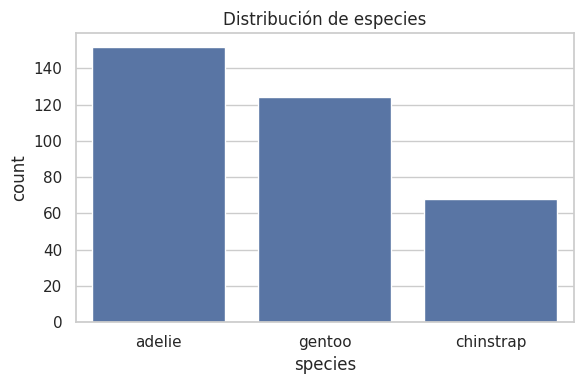

In [6]:
print("Distribución de clases:")
print(df["species"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="species", order=df["species"].value_counts().index)
plt.title("Distribución de especies")
plt.tight_layout()
plt.show()

## 2. Selección de features

- **Numéricas:** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
- **Categóricas:** `island`, `sex`
- **Excluido:** `year` (no tiene relación biológica con la especie)

In [7]:
NUMERIC_FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
CATEGORICAL_FEATURES = ["island", "sex"]
TARGET = "species"

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}  |  Clases: {y.nunique()}")
X.head()

Features: 6  |  Samples: 344  |  Clases: 3


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex
0,39.1,18.7,181.0,3750.0,torgersen,male
1,39.5,17.4,186.0,3800.0,torgersen,female
2,40.3,18.0,195.0,3250.0,torgersen,female
3,38.8,18.4,190.0,3700.0,torgersen,unknown
4,36.7,19.3,193.0,3450.0,torgersen,female


## 3. Split estratificado 70 / 15 / 15

Dos llamadas a `train_test_split` con `stratify=y` para mantener la proporción de clases:
1. 70% train / 30% temporal
2. 50/50 del temporal → 15% validation / 15% test

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")
print(f"\nDistribución por split:")
for name, ys in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = ys.value_counts().to_dict()
    print(f"  {name}: {counts}")

Train: 240  |  Val: 52  |  Test: 52

Distribución por split:
  Train: {'adelie': 106, 'gentoo': 87, 'chinstrap': 47}
  Val: {'adelie': 23, 'gentoo': 19, 'chinstrap': 10}
  Test: {'adelie': 23, 'gentoo': 18, 'chinstrap': 11}


## 4. Pipeline de preprocesamiento + modelo

```
ColumnTransformer:
  - StandardScaler → features numéricas
  - OneHotEncoder(handle_unknown="ignore") → features categóricas
→ MLPClassifier (red neuronal)
    - Capas ocultas: 64 → 32 neuronas
    - Activación: ReLU
    - Solver: Adam
    - Máximo 500 épocas
```

- `StandardScaler` es esencial para redes neuronales (sensibles a la escala de las features)
- `handle_unknown="ignore"` para robustez en inferencia
- Arquitectura simple de 2 capas ocultas, suficiente para un dataset pequeño

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
)

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", clf),
    ]
)

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['island', 'sex'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

## 5. Entrenamiento con seguimiento de loss

Entrenamos época por época usando `partial_fit` para calcular el **log-loss** tanto en train como en validación en cada iteración.

In [10]:
# Preprocesar datos
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_val_t = preprocessor.transform(X_val)

# Entrenar época por época
classes = sorted(y.unique())
train_losses = []
val_losses = []
n_epochs = 500

for epoch in range(1, n_epochs + 1):
    clf.partial_fit(X_train_t, y_train, classes=classes)

    # Loss de entrenamiento (calculado internamente por sklearn)
    train_losses.append(clf.loss_)

    # Loss de validación (log-loss)
    val_proba = clf.predict_proba(X_val_t)
    val_losses.append(log_loss(y_val, val_proba))

best_val_epoch = int(np.argmin(val_losses)) + 1

print(f"Entrenamiento completado — {n_epochs} épocas")
print(f"Train loss final: {train_losses[-1]:.6f}")
print(f"Val loss final:   {val_losses[-1]:.6f}")
print(f"Mejor val loss:   {min(val_losses):.6f} (época {best_val_epoch})")

Entrenamiento completado — 500 épocas
Train loss final: 0.001587
Val loss final:   0.011377
Mejor val loss:   0.011377 (época 500)


## 6. Evaluación

Métricas de clasificación en los tres splits: train (sanity check), validation y test.

In [11]:
for name, Xs, ys in [("TRAIN", X_train, y_train), ("VALIDATION", X_val, y_val), ("TEST", X_test, y_test)]:
    y_pred = pipeline.predict(Xs)
    acc = accuracy_score(ys, y_pred)
    print(f"{'=' * 45}")
    print(f"  {name}  —  accuracy: {acc:.4f}")
    print(f"{'=' * 45}")
    print(classification_report(ys, y_pred))

  TRAIN  —  accuracy: 1.0000
              precision    recall  f1-score   support

      adelie       1.00      1.00      1.00       106
   chinstrap       1.00      1.00      1.00        47
      gentoo       1.00      1.00      1.00        87

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

  VALIDATION  —  accuracy: 1.0000
              precision    recall  f1-score   support

      adelie       1.00      1.00      1.00        23
   chinstrap       1.00      1.00      1.00        10
      gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52

  TEST  —  accuracy: 1.0000
              precision    recall  f1-score   support

      adelie       1.00      1.00      1.00        23
   chinstrap       1.00      1.00     

## 7. Matrices de confusión

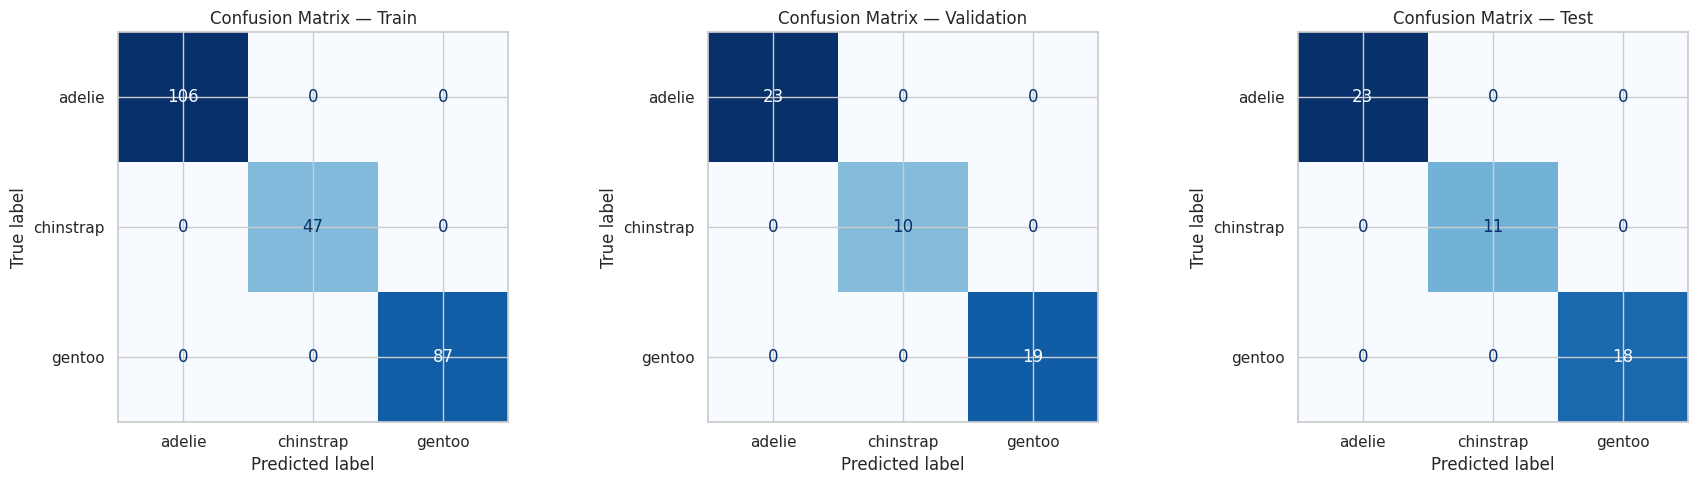

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = sorted(y.unique())

for ax, (name, Xs, ys) in zip(axes, [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]):
    y_pred = pipeline.predict(Xs)
    cm = confusion_matrix(ys, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")

plt.tight_layout()
plt.show()

## 8. Curva de pérdida — Train vs Validación

Comparación del loss de entrenamiento y validación en cada época. Permite detectar **overfitting** (cuando val loss sube mientras train loss baja).

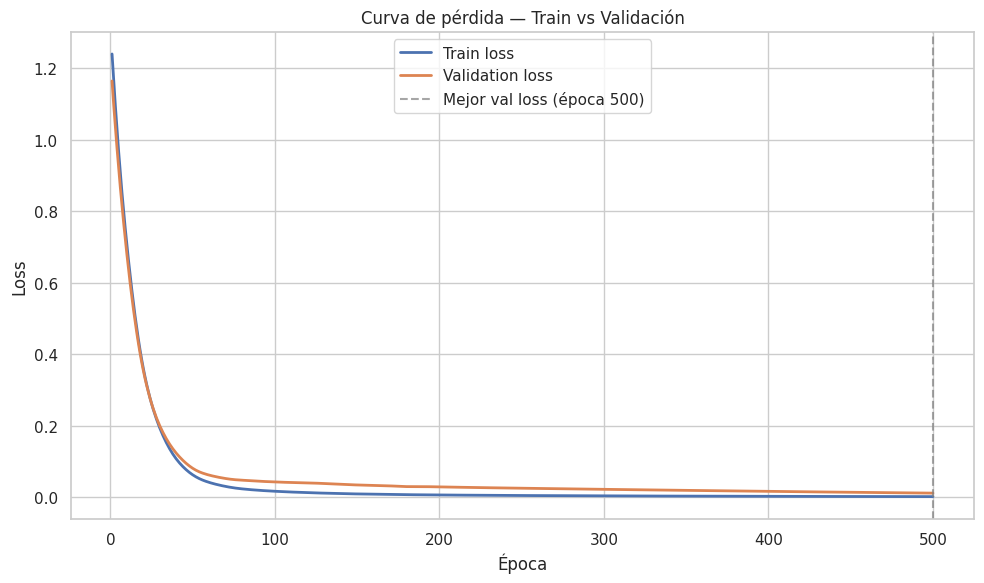

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, len(train_losses) + 1)

ax.plot(epochs, train_losses, label="Train loss", linewidth=2)
ax.plot(epochs, val_losses, label="Validation loss", linewidth=2)
ax.axvline(best_val_epoch, color="gray", linestyle="--", alpha=0.7, label=f"Mejor val loss (época {best_val_epoch})")

ax.set_title("Curva de pérdida — Train vs Validación")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## 9. Guardado del modelo

Se serializa el pipeline completo (preprocesamiento + modelo) en `app/models/species_classifier.joblib`.

In [14]:
MODEL_DIR = ROOT / "app" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "species_classifier.joblib"
joblib.dump(pipeline, MODEL_PATH)

print(f"Modelo guardado en: {MODEL_PATH}")
print(f"Tamaño: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

Modelo guardado en: app/models/species_classifier.joblib
Tamaño: 87.8 KB


In [15]:
# Verificación: cargar el modelo y predecir
loaded = joblib.load(MODEL_PATH)
sample = X_test.head(5)
preds = loaded.predict(sample)
real = y_test.head(5).values

print("Verificación del modelo cargado:")
for i, (pred, actual) in enumerate(zip(preds, real)):
    match = "OK" if pred == actual else "MISS"
    print(f"  [{match}] Predicción: {pred:>10}  |  Real: {actual}")

Verificación del modelo cargado:
  [OK] Predicción:  chinstrap  |  Real: chinstrap
  [OK] Predicción:     adelie  |  Real: adelie
  [OK] Predicción:     gentoo  |  Real: gentoo
  [OK] Predicción:     adelie  |  Real: adelie
  [OK] Predicción:     adelie  |  Real: adelie
